<table style="width:100%;">
  <tr>
    <td style="text-align: left; vertical-align: middle;">
      <h2>Ciência de Dados</h2>
      <p>
        Prof. Túlio Ribeiro<br>
        <br>
        Núcleo de Ciência de Dados e Inteligência Artificial (NCDIA)<br>
        <br>
        Universidade de Fortaleza
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle;">
      <img src="https://www.unifor.br/o/unifor-theme/images/unifor-logo-horizontal.svg" width="200px">
    </td>
  </tr>
</table>

# Distribuições

Neste notebook, usamos dados reais para reconhecer formatos de distribuição e relacioná-los a modelos probabilísticos. O objetivo não é provar que os dados seguem um modelo, mas entender **quando cada distribuição pode ser útil e quais hipóteses precisam ser verificadas**.

**Dados utilizados**

- partidas, gols e disputas de pênaltis de seleções: [International Football Results](https://github.com/martj42/international_results/tree/394fe81893b062fbc2cf6257e988ac7cc4c039a1);
- medidas corporais de pinguins: [Palmer Penguins](https://github.com/allisonhorst/palmerpenguins/tree/8957207b78d6ccd1b4654a9dd9c9041b657478ab).

Os dois projetos disponibilizam os dados sob licença **CC0**. As URLs abaixo estão fixadas em commits específicos para manter os resultados reprodutíveis.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

URL_RESULTADOS = "https://raw.githubusercontent.com/martj42/international_results/394fe81893b062fbc2cf6257e988ac7cc4c039a1/results.csv"
URL_GOLS = "https://raw.githubusercontent.com/martj42/international_results/394fe81893b062fbc2cf6257e988ac7cc4c039a1/goalscorers.csv"
URL_PENALTIS = "https://raw.githubusercontent.com/martj42/international_results/394fe81893b062fbc2cf6257e988ac7cc4c039a1/shootouts.csv"
URL_PINGUINS = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/8957207b78d6ccd1b4654a9dd9c9041b657478ab/inst/extdata/penguins.csv"

sns.set_theme(style="whitegrid", palette="deep")

## Conjuntos de dados e significado das colunas

Cada arquivo possui uma unidade de análise diferente.

### Partidas — uma linha por jogo

| Coluna | Descrição |
|---|---|
| `data` | Data da partida. |
| `mandante` | Seleção registrada como mandante. |
| `visitante` | Seleção registrada como visitante. |
| `gols_mandante` | Gols do mandante antes da disputa de pênaltis. |
| `gols_visitante` | Gols do visitante antes da disputa de pênaltis. |
| `competicao` | Nome da competição. |
| `cidade` | Cidade da partida. |
| `pais` | País onde a partida ocorreu. |
| `campo_neutro` | Indica se a partida ocorreu em campo neutro. |
| `edicao` | Ano da Copa, extraído de `data`. |
| `total_gols` | Soma dos gols das duas seleções. |
| `saldo_gols` | Gols do mandante menos os gols do visitante. |
| `resultado` | Vitória do mandante, vitória do visitante ou empate. |

### Gols — uma linha por gol

| Coluna | Descrição |
|---|---|
| `data` | Data da partida. |
| `mandante` | Seleção mandante. |
| `visitante` | Seleção visitante. |
| `jogador` | Jogador associado ao gol. |
| `minuto` | Minuto registrado para o gol. |
| `gol_contra` | Indica se o gol foi marcado contra a própria equipe. |

### Disputas de pênaltis — uma linha por disputa

| Coluna | Descrição |
|---|---|
| `data` | Data da partida. |
| `mandante` | Seleção mandante. |
| `visitante` | Seleção visitante. |
| `vencedor` | Seleção vencedora da disputa. |
| `primeiro_cobrador` | Seleção que iniciou as cobranças. |
| `primeiro_venceu` | Indica se o primeiro cobrador venceu a disputa. |

In [ ]:
# Lê as partidas e seleciona as Copas do Mundo realizadas até 2022.
resultados = pd.read_csv(URL_RESULTADOS, parse_dates=["date"]).rename(columns={
    "date": "data",
    "home_team": "mandante",
    "away_team": "visitante",
    "home_score": "gols_mandante",
    "away_score": "gols_visitante",
    "tournament": "competicao",
    "city": "cidade",
    "country": "pais",
    "neutral": "campo_neutro",
})

copa = resultados.loc[
    (resultados["competicao"] == "FIFA World Cup")
    & (resultados["data"].dt.year <= 2022)
].copy().reset_index(drop=True)

# Cria apenas as variáveis usadas nas análises.
copa["edicao"] = copa["data"].dt.year
copa["total_gols"] = copa["gols_mandante"] + copa["gols_visitante"]
copa["saldo_gols"] = copa["gols_mandante"] - copa["gols_visitante"]
copa["resultado"] = np.select(
    [copa["saldo_gols"] > 0, copa["saldo_gols"] < 0],
    ["vitória do mandante", "vitória do visitante"],
    default="empate",
)

In [ ]:
copa.head()

,data,mandante,visitante,gols_mandante,gols_visitante,competicao,cidade,pais,campo_neutro,edicao,total_gols,saldo_gols,resultado
0,1930-07-13,Belgium,United States,0,3,FIFA World Cup,Montevideo,Uruguay,True,1930,3,-3,vitória do visitante
1,1930-07-13,France,Mexico,4,1,FIFA World Cup,Montevideo,Uruguay,True,1930,5,3,vitória do mandante
2,1930-07-14,Brazil,Yugoslavia,1,2,FIFA World Cup,Montevideo,Uruguay,True,1930,3,-1,vitória do visitante
3,1930-07-14,Peru,Romania,1,3,FIFA World Cup,Montevideo,Uruguay,True,1930,4,-2,vitória do visitante
4,1930-07-15,Argentina,France,1,0,FIFA World Cup,Montevideo,Uruguay,True,1930,1,1,vitória do mandante


In [ ]:
# Relaciona cada gol às chaves das partidas de Copa do Mundo.
gols = pd.read_csv(
    URL_GOLS,
    usecols=["date", "home_team", "away_team", "scorer", "minute", "own_goal"],
    parse_dates=["date"],
).rename(columns={
    "date": "data",
    "home_team": "mandante",
    "away_team": "visitante",
    "scorer": "jogador",
    "minute": "minuto",
    "own_goal": "gol_contra",
})

gols.head()

,data,mandante,visitante,jogador,minuto,gol_contra
0,1916-07-02,Chile,Uruguay,José Piendibene,44.0,False
1,1916-07-02,Chile,Uruguay,Isabelino Gradín,55.0,False
2,1916-07-02,Chile,Uruguay,Isabelino Gradín,70.0,False
3,1916-07-02,Chile,Uruguay,José Piendibene,75.0,False
4,1916-07-06,Argentina,Chile,Alberto Ohaco,2.0,False


In [ ]:
# Relaciona cada gol às chaves das partidas de Copa do Mundo.
gols = pd.read_csv(
    URL_GOLS,
    usecols=["date", "home_team", "away_team", "scorer", "minute", "own_goal"],
    parse_dates=["date"],
).rename(columns={
    "date": "data",
    "home_team": "mandante",
    "away_team": "visitante",
    "scorer": "jogador",
    "minute": "minuto",
    "own_goal": "gol_contra",
})

chaves_copa = copa[["data", "mandante", "visitante"]]
gols_copa = gols.merge(
    chaves_copa,
    on=["data", "mandante", "visitante"],
    how="inner",
    validate="many_to_one",
)

In [ ]:
gols_copa.head()

,data,mandante,visitante,jogador,minuto,gol_contra
0,1930-07-13,Belgium,United States,Bart McGhee,23.0,False
1,1930-07-13,Belgium,United States,Tom Florie,45.0,False
2,1930-07-13,Belgium,United States,Bert Patenaude,69.0,False
3,1930-07-13,France,Mexico,Lucien Laurent,19.0,False
4,1930-07-13,France,Mexico,Marcel Langiller,40.0,False


In [ ]:
# Mantém somente as disputas de pênaltis ocorridas nas Copas selecionadas.
penaltis = pd.read_csv(URL_PENALTIS, parse_dates=["date"]).rename(columns={
    "date": "data",
    "home_team": "mandante",
    "away_team": "visitante",
    "winner": "vencedor",
    "first_shooter": "primeiro_cobrador",
})

penaltis.head()

,data,mandante,visitante,vencedor,primeiro_cobrador
0,1967-08-22,India,Taiwan,Taiwan,NaN
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NaN
2,1972-05-07,South Korea,Iraq,Iraq,NaN
3,1972-05-17,Thailand,South Korea,South Korea,NaN
4,1972-05-19,Thailand,Cambodia,Thailand,NaN


In [ ]:
disputas_copa = penaltis.merge(
    chaves_copa,
    on=["data", "mandante", "visitante"],
    how="inner",
    validate="one_to_one",
)
disputas_copa["primeiro_venceu"] = (
    disputas_copa["vencedor"] == disputas_copa["primeiro_cobrador"]
)

In [ ]:
disputas_copa.head()

,data,mandante,visitante,vencedor,primeiro_cobrador,primeiro_venceu
0,1982-07-08,Germany,France,Germany,France,False
1,1986-06-21,Brazil,France,France,Brazil,False
2,1986-06-21,Mexico,Germany,Germany,Germany,True
3,1986-06-22,Spain,Belgium,Belgium,Spain,False
4,1990-06-25,Republic of Ireland,Romania,Republic of Ireland,Romania,False


### Pinguins — uma linha por indivíduo

| Coluna | Descrição |
|---|---|
| `especie` | Espécie do pinguim. |
| `comprimento_nadadeira_mm` | Comprimento da nadadeira, em milímetros. |
| `massa_corporal_g` | Massa corporal, em gramas. |
| `sexo` | Sexo registrado do animal. |

In [ ]:
# Lê somente as medidas necessárias para os exemplos deste notebook.
pinguins = pd.read_csv(
    URL_PINGUINS,
    usecols=["species", "flipper_length_mm", "body_mass_g", "sex"],
).rename(columns={
    "species": "especie",
    "flipper_length_mm": "comprimento_nadadeira_mm",
    "body_mass_g": "massa_corporal_g",
    "sex": "sexo",
})

pinguins["sexo"] = pinguins["sexo"].replace({
    "male": "macho",
    "female": "fêmea",
})

In [ ]:
pinguins.head()

,especie,comprimento_nadadeira_mm,massa_corporal_g,sexo
0,Adelie,181.0,3750.0,macho
1,Adelie,186.0,3800.0,fêmea
2,Adelie,195.0,3250.0,fêmea
3,Adelie,NaN,NaN,NaN
4,Adelie,193.0,3450.0,fêmea


In [ ]:
pd.Series({
    "partidas de Copa": len(copa),
    "gols em Copas": len(gols_copa),
    "disputas de pênaltis em Copas": len(disputas_copa),
    "pinguins": len(pinguins),
}, name="registros").to_frame()

,registros
partidas de Copa,964
gols em Copas,2720
disputas de pênaltis em Copas,35
pinguins,344


## 1. Distribuições simétricas e assimétricas

Uma distribuição é **simétrica** quando seus lados possuem formatos semelhantes em torno do centro. Ela é **assimétrica** quando uma das caudas se prolonga mais.

A assimetria populacional pode ser resumida pelo terceiro momento padronizado:

$$\gamma_1=\frac{E[(X-\mu)^3]}{\sigma^3}$$

Valores positivos indicam cauda mais longa à direita; valores negativos, à esquerda. A medida ajuda a escolher resumos e modelos, mas não determina sozinha uma ordem universal entre média, mediana e moda.

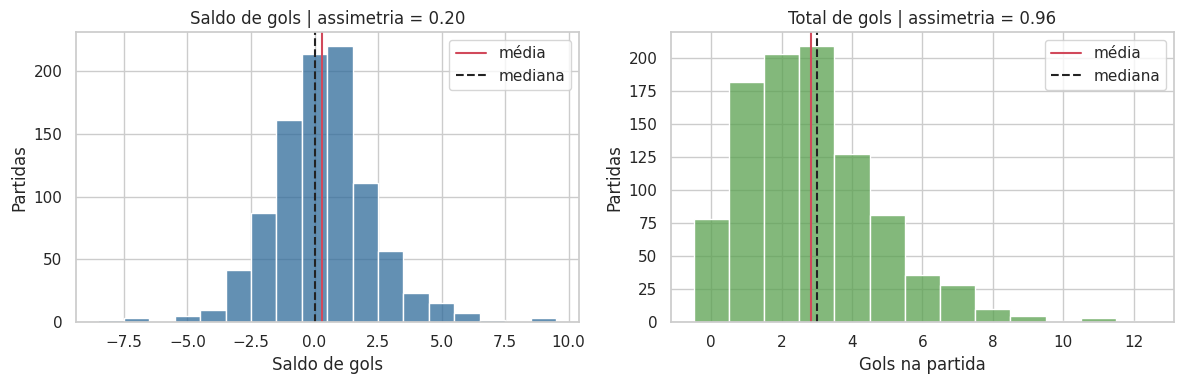

In [ ]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(copa["saldo_gols"], discrete=True, ax=eixos[0], color="#2F6B9A")
eixos[0].axvline(copa["saldo_gols"].mean(), color="#D1495B", label="média")
eixos[0].axvline(copa["saldo_gols"].median(), color="#222222", linestyle="--", label="mediana")
eixos[0].set(title=f"Saldo de gols | assimetria = {copa['saldo_gols'].skew():.2f}", xlabel="Saldo de gols", ylabel="Partidas")
eixos[0].legend()

sns.histplot(copa["total_gols"], discrete=True, ax=eixos[1], color="#59A14F")
eixos[1].axvline(copa["total_gols"].mean(), color="#D1495B", label="média")
eixos[1].axvline(copa["total_gols"].median(), color="#222222", linestyle="--", label="mediana")
eixos[1].set(title=f"Total de gols | assimetria = {copa['total_gols'].skew():.2f}", xlabel="Gols na partida", ylabel="Partidas")
eixos[1].legend()

plt.tight_layout()
plt.show()

**Figura 1 — Formato das distribuições.** O saldo de gols é aproximadamente simétrico, enquanto o total de gols apresenta cauda à direita: muitas partidas têm poucos gols e poucas partidas têm totais elevados.

## 2. Função de distribuição acumulada empírica (ECDF)

A ECDF informa a proporção de observações menores ou iguais a um valor $x$:

$$\widehat{F}(x)=\frac{1}{n}\sum_{i=1}^{n}I(x_i\leq x)$$

Ela é útil para localizar percentis e comparar distribuições sem escolher intervalos de histograma. Cada degrau representa observações acumuladas.

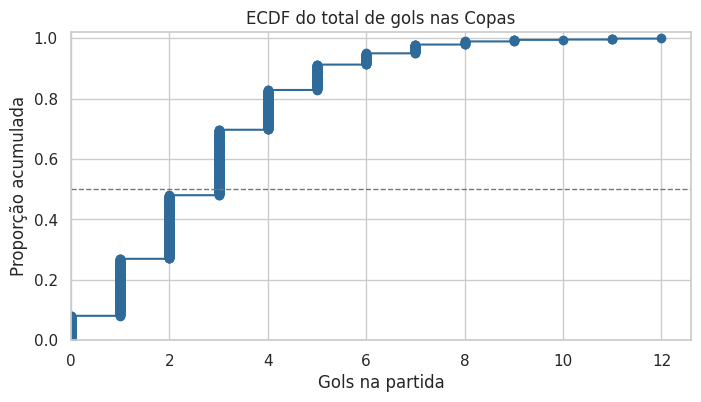

In [ ]:
plt.figure(figsize=(8, 4))
sns.ecdfplot(data=copa, x="total_gols", marker="o", color="#2F6B9A")
plt.axhline(0.5, color="#777777", linestyle="--", linewidth=1)
plt.xlabel("Gols na partida")
plt.ylabel("Proporção acumulada")
plt.title("ECDF do total de gols nas Copas")
plt.xlim(left=0)
plt.ylim(0, 1.02)
plt.show()

**Figura 2 — ECDF do total de gols.** Aproximadamente 70% das partidas terminaram com até três gols. O ponto em que a curva alcança 0,5 corresponde à mediana.

## 3. Distribuição Normal

A Normal é uma distribuição contínua, simétrica e definida por média $\mu$ e desvio-padrão $\sigma$:

$$f(x)=\frac{1}{\sigma\sqrt{2\pi}}\exp\left[-\frac{(x-\mu)^2}{2\sigma^2}\right]$$

Ela pode representar medidas produzidas pela combinação de muitos efeitos pequenos. Se $X\sim N(\mu,\sigma^2)$, cerca de 68%, 95% e 99,7% dos valores ficam, respectivamente, a um, dois e três desvios-padrão da média. Essa regra é específica da Normal.

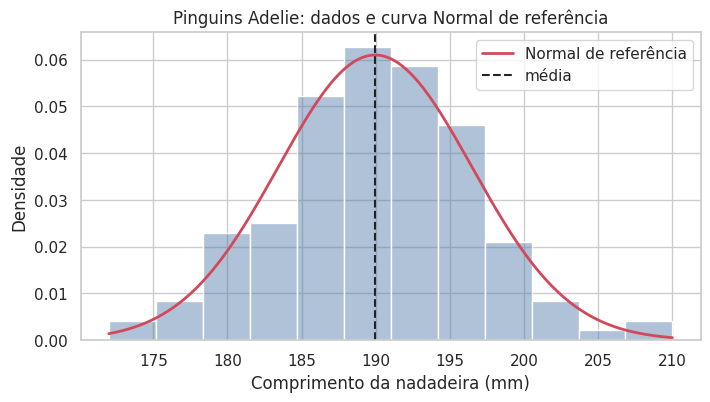

In [ ]:
nadadeira_adelie = pinguins.loc[
    pinguins["especie"] == "Adelie", "comprimento_nadadeira_mm"
].dropna()

media_adelie = nadadeira_adelie.mean()
desvio_adelie = nadadeira_adelie.std()
x_normal = np.linspace(nadadeira_adelie.min(), nadadeira_adelie.max(), 300)

plt.figure(figsize=(8, 4))
sns.histplot(nadadeira_adelie, bins=12, stat="density", color="#4E79A7", alpha=0.45)
plt.plot(
    x_normal,
    stats.norm.pdf(x_normal, loc=media_adelie, scale=desvio_adelie),
    color="#D1495B",
    linewidth=2,
    label="Normal de referência",
)
plt.axvline(media_adelie, color="#222222", linestyle="--", label="média")
plt.xlabel("Comprimento da nadadeira (mm)")
plt.ylabel("Densidade")
plt.title("Pinguins Adelie: dados e curva Normal de referência")
plt.legend()
plt.show()

**Figura 3 — Normal como referência.** A curva usa a média e o desvio-padrão observados nos pinguins Adelie. A semelhança visual ajuda a formular uma hipótese, mas não comprova Normalidade.

In [ ]:
cobertura = []
for desvios, teorico in [(1, 68.3), (2, 95.4), (3, 99.7)]:
    limite_inferior = media_adelie - desvios * desvio_adelie
    limite_superior = media_adelie + desvios * desvio_adelie
    observado = nadadeira_adelie.between(limite_inferior, limite_superior).mean() * 100
    cobertura.append([f"μ ± {desvios}σ", teorico, observado])

pd.DataFrame(
    cobertura,
    columns=["Intervalo", "Normal teórica (%)", "Adelie observado (%)"],
).round(1)

,Intervalo,Normal teórica (%),Adelie observado (%)
0,μ ± 1σ,68.3,70.9
1,μ ± 2σ,95.4,96.0
2,μ ± 3σ,99.7,99.3


As proporções observadas são próximas à regra 68–95–99,7, mas a decisão sobre um modelo também deve considerar o processo gerador, o tamanho da amostra e diagnósticos adicionais.

## 4. Lei de potência e distribuição de Pareto

Em uma cauda de Pareto, valores grandes tornam-se raros de forma lenta. Sua função de sobrevivência é:

$$P(X\geq x)=\left(\frac{x_{\min}}{x}\right)^{\alpha},\qquad x\geq x_{\min}$$

Esse modelo aparece em fenômenos de forte concentração. Um gráfico da CCDF em escala log–log ajuda a examinar a cauda: um trecho aproximadamente linear é apenas um indício, não uma prova de lei de potência.

In [ ]:
# Gols contra permanecem no total das partidas, mas não contam para o artilheiro.
gols_validos = gols_copa.loc[~gols_copa["gol_contra"]]
gols_validos

,data,mandante,visitante,jogador,minuto,gol_contra
0,1930-07-13,Belgium,United States,Bart McGhee,23.0,False
1,1930-07-13,Belgium,United States,Tom Florie,45.0,False
2,1930-07-13,Belgium,United States,Bert Patenaude,69.0,False
3,1930-07-13,France,Mexico,Lucien Laurent,19.0,False
4,1930-07-13,France,Mexico,Marcel Langiller,40.0,False
...,...,...,...,...,...,...
2715,2022-12-18,Argentina,France,Ángel Di María,36.0,False
2716,2022-12-18,Argentina,France,Kylian Mbappé,80.0,False
2717,2022-12-18,Argentina,France,Kylian Mbappé,81.0,False
2718,2022-12-18,Argentina,France,Lionel Messi,109.0,False


In [ ]:
gols_por_jogador = gols_validos.groupby("jogador").size()
gols_por_jogador

,0
jogador,
Abdeljalil Hadda,2
Abdelkrim Merry,1
Abdelmoumene Djabou,2
Abderrazak Khairi,2
Abdullah Al-Buloushi,1
...,...
Đorđe Vujadinović,2
İlhan Mansız,3
İlkay Gündoğan,1


In [ ]:
valores_gols = np.sort(gols_por_jogador.unique())
valores_gols

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16])

In [ ]:
ccdf = [(gols_por_jogador >= valor).mean() for valor in valores_gols]
ccdf

[np.float64(1.0),
 np.float64(0.3803019410496046),
 np.float64(0.19841840402588065),
 np.float64(0.11646297627606039),
 np.float64(0.07260963335729691),
 np.float64(0.04744787922358016),
 np.float64(0.029475197699496764),
 np.float64(0.02372393961179008),
 np.float64(0.017972681524083392),
 np.float64(0.010783608914450037),
 np.float64(0.006470165348670022),
 np.float64(0.0050323508267433505),
 np.float64(0.0035945363048166786),
 np.float64(0.002156721782890007),
 np.float64(0.0014378145219266715),
 np.float64(0.0007189072609633358)]

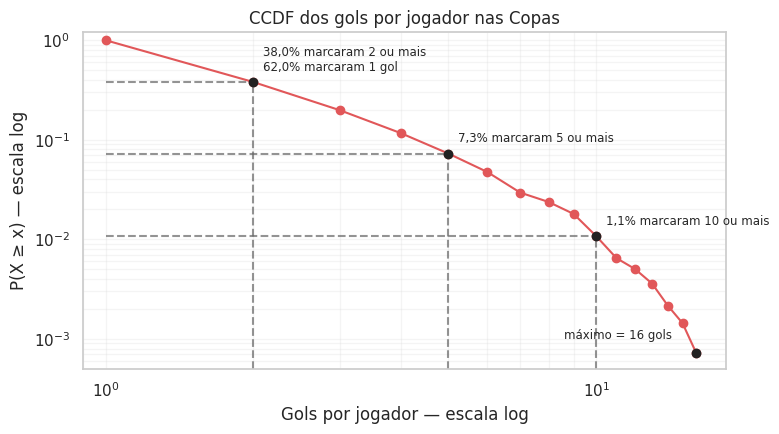

In [ ]:
# Pontos usados para facilitar a leitura da cauda.
proporcao_um_gol = (gols_por_jogador == 1).mean()
proporcoes = {
    limite: (gols_por_jogador >= limite).mean()
    for limite in [2, 5, 10]
}
maximo_gols = gols_por_jogador.max()
proporcao_maximo = (gols_por_jogador >= maximo_gols).mean()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.loglog(valores_gols, ccdf, "o-", color="#E15759")

# As linhas ligam cada limiar à proporção correspondente.
limite_inferior = min(ccdf) * 0.7
for limite, proporcao in proporcoes.items():
    ax.vlines(limite, limite_inferior, proporcao, color="#666666", linestyle="--", alpha=0.7)
    ax.hlines(proporcao, 1, limite, color="#666666", linestyle="--", alpha=0.7)
    ax.scatter(limite, proporcao, color="#222222", zorder=3)

rotulos = {
    2: f"{proporcoes[2]:.1%} marcaram 2 ou mais\n{proporcao_um_gol:.1%} marcaram 1 gol",
    5: f"{proporcoes[5]:.1%} marcaram 5 ou mais",
    10: f"{proporcoes[10]:.1%} marcaram 10 ou mais",
}
for limite, texto in rotulos.items():
    ax.annotate(texto.replace(".", ","), (limite, proporcoes[limite]), xytext=(7, 8), textcoords="offset points", fontsize=8.5)

ax.scatter(maximo_gols, proporcao_maximo, color="#222222", zorder=3)
ax.annotate(f"máximo = {maximo_gols} gols", (maximo_gols, proporcao_maximo), xytext=(-95, 10), textcoords="offset points", fontsize=8.5)
ax.set(xlabel="Gols por jogador — escala log", ylabel="P(X ≥ x) — escala log", title="CCDF dos gols por jogador nas Copas")
ax.set_xlim(0.9, maximo_gols * 1.15)
ax.set_ylim(limite_inferior, 1.2)
ax.grid(True, which="both", alpha=0.2)
plt.tight_layout()
plt.show()

**Figura 4 — Concentração de gols por jogador.** A CCDF cai rapidamente: muitos jogadores marcaram uma vez e poucos alcançaram totais altos. O formato sugere uma cauda pesada, mas identificar Pareto exigiria definir o início da cauda, estimar $\alpha$ e avaliar o ajuste.

## 5. Distribuição bimodal

Uma distribuição **bimodal** possui duas regiões de maior frequência. Isso pode ocorrer quando a amostra combina dois grupos com centros diferentes.

A bimodalidade é uma característica do formato, não um modelo probabilístico único. Antes de resumir tudo por uma média, convém procurar grupos que expliquem os dois picos.

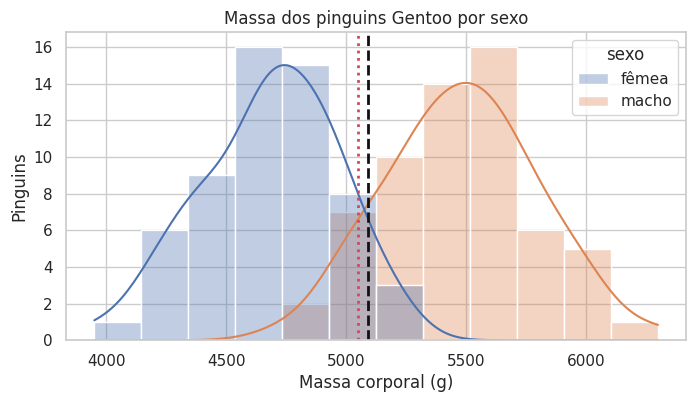

In [ ]:
gentoo = pinguins.loc[
    (pinguins["especie"] == "Gentoo") & pinguins["sexo"].notna()
].copy()

media_gentoo = gentoo["massa_corporal_g"].mean()
mediana_gentoo = gentoo["massa_corporal_g"].median()

plt.figure(figsize=(8, 4))
ax = sns.histplot(
    data=gentoo,
    x="massa_corporal_g",
    hue="sexo",
    bins=12,
    kde=True,
    alpha=0.35,
)
ax.axvline(media_gentoo, color="#111111", linestyle="--", linewidth=2)
ax.axvline(mediana_gentoo, color="#D1495B", linestyle=":", linewidth=2)
ax.set(xlabel="Massa corporal (g)", ylabel="Pinguins", title="Massa dos pinguins Gentoo por sexo")
plt.show()

**Figura 5 — Bimodalidade e grupos.** As massas de fêmeas e machos formam regiões distintas e ajudam a explicar os dois picos. A linha preta tracejada representa a média geral; a vermelha pontilhada, a mediana geral.

In [ ]:
np.mean(gentoo[gentoo['sexo'] == 'macho']['massa_corporal_g'])

np.float64(5484.836065573771)

## 6. Distribuição Binomial

A Binomial modela o número $X$ de sucessos em $n$ tentativas com dois resultados possíveis:

$$P(X=k)=\binom{n}{k}p^k(1-p)^{n-k},\qquad k=0,1,\ldots,n$$

Ela é apropriada quando $n$ é fixo, as tentativas são independentes e a probabilidade $p$ permanece constante. Aqui, "sucesso" significa o primeiro cobrador vencer a disputa; equipes, épocas e regras diferentes podem enfraquecer essas hipóteses.

In [ ]:
n_disputas = len(disputas_copa)
vitorias_primeiro = disputas_copa["primeiro_venceu"].sum()
p_primeiro = disputas_copa["primeiro_venceu"].mean()
p_primeiro = 0.5
k_binomial = np.arange(n_disputas + 1)

print(n_disputas)
print(vitorias_primeiro)
print(p_primeiro)
print(k_binomial)

35
17
0.5
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35]


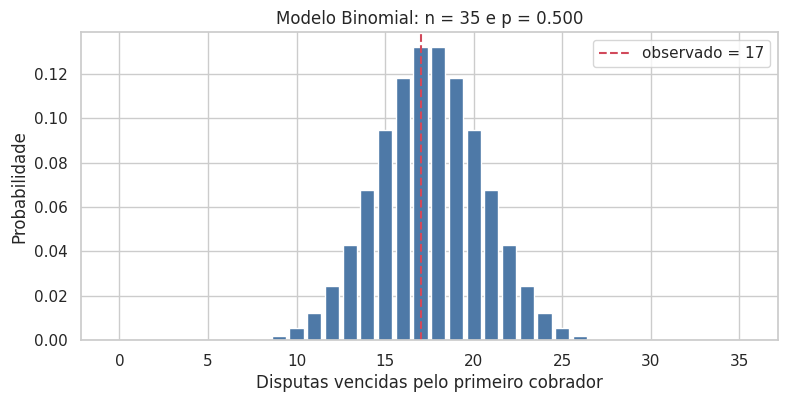

In [ ]:
plt.figure(figsize=(9, 4))
plt.bar(
    k_binomial,
    stats.binom.pmf(k_binomial, n=n_disputas, p=p_primeiro),
    color="#4E79A7",
)
plt.axvline(vitorias_primeiro, color="#D1495B", linestyle="--", label=f"observado = {vitorias_primeiro}")
plt.xlabel("Disputas vencidas pelo primeiro cobrador")
plt.ylabel("Probabilidade")
plt.title(f"Modelo Binomial: n = {n_disputas} e p = {p_primeiro:.3f}")
plt.legend()
plt.show()

**Figura 6 — Modelo Binomial.** O primeiro cobrador venceu 17 das 35 disputas, proporção usada como $p$. A curva mostra totais possíveis sob as hipóteses do modelo; ela não demonstra vantagem nem desvantagem causal de cobrar primeiro.

## 7. Distribuição de Poisson

A Poisson modela a contagem $X$ de eventos em um intervalo fixo:

$$P(X=k)=e^{-\lambda}\frac{\lambda^k}{k!},\qquad k=0,1,2,\ldots$$

O parâmetro $\lambda$ é a contagem média por intervalo. O modelo supõe eventos aproximadamente independentes e taxa constante. Gols por partida são um exemplo intuitivo, mas equipes, placar e duração do jogo podem alterar a taxa.

In [ ]:
lambda_gols = copa["total_gols"].mean()
print(lambda_gols)

2.8215767634854774


In [ ]:
k_poisson = np.arange(copa["total_gols"].max() + 1)
print(k_poisson)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12]


In [ ]:
frequencia_observada = (
    copa["total_gols"].value_counts(normalize=True).reindex(k_poisson, fill_value=0)
)
print(frequencia_observada)

total_gols
0     0.080913
1     0.188797
2     0.210581
3     0.216805
4     0.131743
5     0.084025
6     0.037344
7     0.029046
8     0.010373
9     0.005187
10    0.001037
11    0.003112
12    0.001037
Name: proportion, dtype: float64


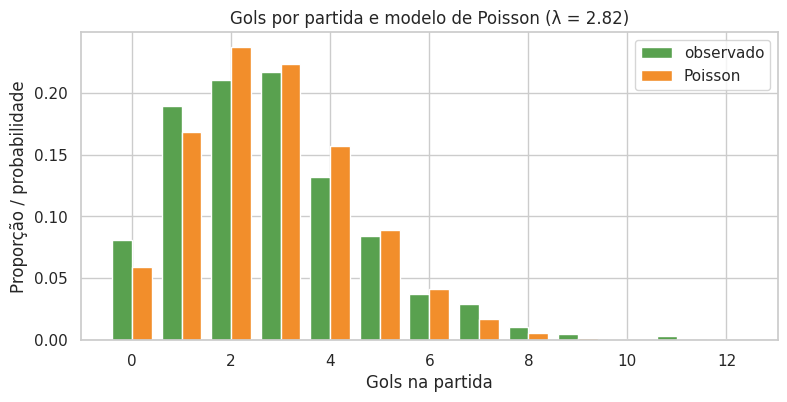

In [ ]:
plt.figure(figsize=(9, 4))
plt.bar(k_poisson - 0.2, frequencia_observada, width=0.4, label="observado", color="#59A14F")
plt.bar(
    k_poisson + 0.2,
    stats.poisson.pmf(k_poisson, mu=lambda_gols),
    width=0.4,
    label="Poisson",
    color="#F28E2B",
)
plt.xlabel("Gols na partida")
plt.ylabel("Proporção / probabilidade")
plt.title(f"Gols por partida e modelo de Poisson (λ = {lambda_gols:.2f})")
plt.legend()
plt.show()

**Figura 7 — Contagens e Poisson.** A PMF teórica, parametrizada pela média de 2,82 gols, serve como referência para as frequências observadas. O suporte da Poisson é infinito; o gráfico mostra de zero ao maior total observado, sem afirmar ajuste do modelo.

## 8. Distribuição Exponencial

A Exponencial modela o tempo contínuo $T$ até o próximo evento:

$$f(t)=\lambda e^{-\lambda t},\qquad t\geq 0, \qquad E(T)=\frac{1}{\lambda}$$

Ela se relaciona a um processo de Poisson com taxa constante e intervalos independentes. No futebol, o tempo entre gols é um exemplo didático, mas o ritmo muda durante a partida e jogos sem um próximo gol geram censura.

In [ ]:
# Calcula a diferença entre gols consecutivos dentro de cada partida.
gols_ordenados = gols_copa.sort_values(
    ["data", "mandante", "visitante", "minuto"]
)

gols_ordenados

,data,mandante,visitante,jogador,minuto,gol_contra
0,1930-07-13,Belgium,United States,Bart McGhee,23.0,False
1,1930-07-13,Belgium,United States,Tom Florie,45.0,False
2,1930-07-13,Belgium,United States,Bert Patenaude,69.0,False
3,1930-07-13,France,Mexico,Lucien Laurent,19.0,False
4,1930-07-13,France,Mexico,Marcel Langiller,40.0,False
...,...,...,...,...,...,...
2715,2022-12-18,Argentina,France,Ángel Di María,36.0,False
2716,2022-12-18,Argentina,France,Kylian Mbappé,80.0,False
2717,2022-12-18,Argentina,France,Kylian Mbappé,81.0,False
2718,2022-12-18,Argentina,France,Lionel Messi,109.0,False


In [ ]:
intervalos = gols_ordenados.groupby(
    ["data", "mandante", "visitante"]
)["minuto"].diff()
intervalos

,minuto
0,NaN
1,22.0
2,24.0
3,NaN
4,21.0
...,...
2715,13.0
2716,44.0
2717,1.0
2718,28.0


In [ ]:
# Mantém intervalos positivos; gols no mesmo minuto têm resolução insuficiente.
intervalos = intervalos[intervalos > 0]
lambda_intervalos = 1 / intervalos.mean()
x_exponencial = np.linspace(0, intervalos.max(), 300)

print(lambda_intervalos)
print(x_exponencial[:10])

0.052273900326891096
[0.         0.29431438 0.58862876 0.88294314 1.17725753 1.47157191
 1.76588629 2.06020067 2.35451505 2.64882943]


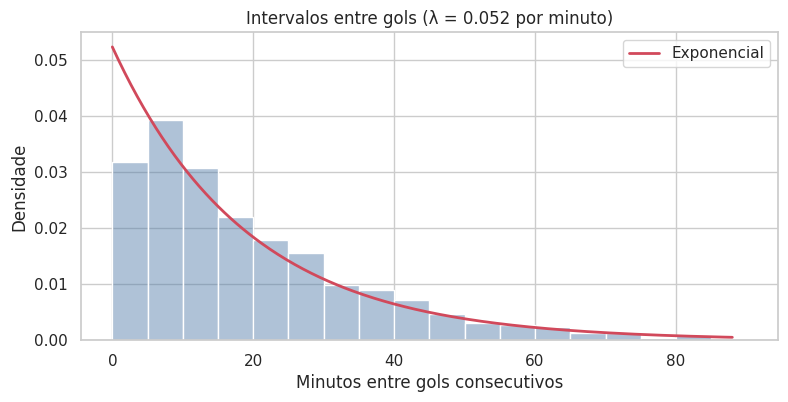

In [ ]:
plt.figure(figsize=(9, 4))
sns.histplot(intervalos, bins=np.arange(0, intervalos.max() + 5, 5), stat="density", color="#4E79A7", alpha=0.45)
plt.plot(
    x_exponencial,
    stats.expon.pdf(x_exponencial, scale=1 / lambda_intervalos),
    color="#D1495B",
    linewidth=2,
    label="Exponencial",
)
plt.xlabel("Minutos entre gols consecutivos")
plt.ylabel("Densidade")
plt.title(f"Intervalos entre gols (λ = {lambda_intervalos:.3f} por minuto)")
plt.legend()
plt.show()

**Figura 8 — Tempos entre gols e Exponencial.** A curva usa o intervalo médio observado, cerca de 19 minutos. O exemplo exclui intervalos iguais a zero, reinicia a contagem em cada partida e inclui prorrogações; censura e taxa variável limitam a interpretação do modelo.

## Resumo

| Fenômeno | Distribuição possível | Parâmetros | Hipóteses principais | Quando não usar |
|---|---|---|---|---|
| Medidas contínuas aproximadamente simétricas | Normal | $\mu$ e $\sigma$ | Simetria e formato compatível | Dados fortemente assimétricos ou multimodais |
| Concentração com valores extremos | Pareto | $x_{\min}$ e $\alpha$ | Cauda compatível acima de $x_{\min}$ | Apenas porque o gráfico log–log parece linear |
| Mistura de dois grupos | Bimodal | Modos e pesos dos grupos | Existência de dois processos ou grupos | Quando os picos resultam apenas de poucos dados ou escolha de intervalos |
| Sucessos em $n$ tentativas | Binomial | $n$ e $p$ | Tentativas independentes e $p$ constante | Mais de dois resultados ou probabilidades muito variáveis |
| Eventos em intervalo fixo | Poisson | $\lambda$ | Taxa constante e eventos independentes | Contagens com excesso de variabilidade, dependência ou taxa variável |
| Espera entre eventos | Exponencial | $\lambda$ | Taxa constante e ausência de memória | Censura ignorada, dependência ou taxa variável |
| Proporção acumulada observada | ECDF | Não exige parâmetro | Amostra representa a população de interesse | Quando se deseja extrapolar além dos dados observados |

## Exercícios

1. Use a ECDF para estimar a proporção de partidas com até dois gols.
2. Compare a distribuição de `total_gols` antes e depois de 1990.
3. Refaça a análise Normal para outra espécie de pinguim.
4. Calcule a probabilidade binomial de exatamente 17 vitórias em 35 disputas usando $p=0{,}5$.
5. Compare a média prevista pela Exponencial com a mediana observada dos intervalos entre gols.